In [2]:
cbbP = ["#000000", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]

from sage.geometry.hyperbolic_space.hyperbolic_geodesic import HyperbolicGeodesicPD
from time import time 

class HypLine(HyperbolicGeodesicPD):
    r"""
    Extension of the functionality of `HyperbolicGeodesicPD`. We work
    over a multiprecision field to make computations faster, as 
    otherwise computations are done over the symbolic ring, which
    quickly becomes inefficient. 
    """
    def __init__(self, start, end, prec=53):
        PD = HyperbolicPlane().PD()
        self._prec = prec
        self._k = ComplexField(prec)
        self._P1 = self._k(start)
        self._P2 = self._k(end)
        super(HypLine, self).__init__(PD, PD(start), PD(end))
    
    def centre(self):
        r"""
        Return the centre of the cirle whose arc is the geodesic.
        """
        # Let's nick the formula for intersection from 
        # https://math.stackexchange.com/questions/1352554/intersection-of-two-lines-in-complex-numbers-given-four-points, 
        # using that we have z1 = p1, z2 = (1+I)*p1, z3 = p2, z = (1+I)*p2. 
        # This is only relevant if P1 and P2 lie on the unit circle, so we need to complete and extract
        # the endpoints. 
        eps = self.complete().endpoints()
        p1, p2 = tuple(self._k(ei.coordinates()) for ei in eps)
        #p1 = self._P1
        #p2 = self._P2 
        
        if (p1+p2).abs()<self._k(2)**(-self._prec+3):
            return self._k(Infinity)*(1+self._k(sqrt(-1)))
        
        return (p2.abs()^2*p1-p1.abs()^2*p2)*self._k(sqrt(-1))/(p1.conjugate()*p2).imag()
    
    def radius(self):
        r"""
        Return the radius of the cirle whose arc is the geodesic.
        """
        return (self.centre()-self._P1).abs()
    
    def _arg_range(self):
        r"""
        Return the range of angles that define the geodesic as an arc of a circle
        """
        z0 = self.centre()
        A1 = (self._P1-z0).arg()
        A2 = (self._P2-z0).arg()
        
        if A1<A2:
            A1, A2 = A2, A1
            
        if A1-A2<pi:
            return RealSet([A1, A2])
        
        return RealSet([A1, pi], [-pi, A2])
    
    def reflect(self, what):
        r"""
        Reflect the geodesic `what` in `self`.
        """
        # Note no effort is made to check that `what` is an instance 
        # of HypLine
        # p1 = self._P1
        # p2 = self._P2
        # Consider the completed line
        eps = self.complete().endpoints()
        p1, p2 = tuple(self._k(ei.coordinates()) for ei in eps)
        
        # Reflecting in a diameter is easy
        if (p1+p2).abs()<self._k(2)**(-self._prec+3):
            return HypLine(p1^2*what._P1.conjugate(), p1^2*what._P2.conjugate())
        
        # Else use https://mphitchman.com/geometry/section3-2.html
        # Related to https://mphitchman.com/geometry/section5-1.html
        c = self.centre()
        r = self.radius()
        
        np1 = r^2/(what._P1-c).conjugate()+c
        #np1 /= np1.abs()
        np2 = r^2/(what._P2-c).conjugate()+c
        #np2 /= np2.abs()
        
        P = min(self._prec, what._prec)
        
        return HypLine(np1, np2, prec=P)
    
    def centralRot(self, angle):
        r"""
        Rotate `self` about the centre of the disk by `angle` radians.
        """
        j = self._k(sqrt(-1))
        # we make no test about compatibility of angle and j
        # rather just hope it works and leave it up to the user (me)
        ea = exp(angle*j)
        
        return HypLine(self._P1*ea, self._P2*ea, prec=self._prec) 
    
    def is_equal(self, what):
        r"""
        Tests for equality of instances of HypLines, by comparing 
        the centre and radius up to the precision tolerance
        """
        centre_error = (self.centre()-what.centre()).abs()
        radius_error = (self.radius()-what.radius()).abs()
        tol = self._k(2)**(-self._prec+3)
        
        return centre_error<tol and radius_error<tol
    
    def intersects(self, what):
        r"""
        Tests whether two HypLines intersect, by looking for intersections.
        """
        return self.is_equal(what) or bool(len(self.numerical_intersection(what)))
    
    def numerical_intersection(self, what):
        r"""
        Return a list of the intersections between `self` and `what`. If `self==what`, 
        return an error. Assumes lines are complete. 
        """
        
        if self.is_equal(what):
            raise ValueError("Cannot give intersection with self")
            
        z0 = self.centre()
        z1 = what.centre()
        r0 = self.radius()
        r1 = what.radius()
        
        if r0+r1 < (z0-z1).abs() or (r0-r1).abs() > (z0-z1).abs():
            return []
        
        z = polygen(self._k)
        pol = (z-z0)*(z-z1)*(z0.conjugate()-z1.conjugate())+r0^2*(z-z1)-r1^2*(z-z0)
        rs = pol.roots(multiplicities=False)
        ar = self._arg_range()
        
        return [ri for ri in rs if ar.contains((ri-z0).arg())]

Starting reflections:
5
20
380
Took 0.5614917278289795 seconds
Starting post-processing:
Took 48.20173907279968 seconds


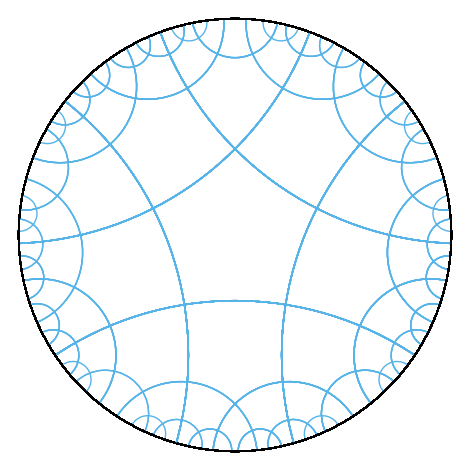

In [3]:
### We collate the calculation process to make it easier to replicate

# First set a precision, which will stay constant throughout 
P = 100
FC = ComplexField(prec=P)

# These are numbers from Harry's calculations, relevant only for the {5,4}_6 tesselation, 
# and we could usurp these later.
SAR = sin(pi/5)/cos(pi/4)
CAR = sqrt(1-SAR^2)

# These numbers set the end-point of the `fundamental' line for the {5,4}. 
# The lines that form this tesselation are all the way along
p1 = SAR-CAR*I
p2 = -SAR-CAR*I
gf = HypLine(p1, p2, prec=P)

print("Starting reflections:")
ct = time()
# Make the first rotations of the line
initial = [gf]+[gf.centralRot(2*pi*k/5) for k in range(1,5)]
print(len(initial))

# gf6 = gf5.reflect(gf4)
# gf7 = gf6.reflect(gf2)
# gf8 = gf5.reflect(gf7)

# First refelection process
first_ref = [gi.reflect(gj) for gi in initial 
             for gj in initial if not gi.is_equal(gj)]
print(len(first_ref))

# Second reflection process
second_ref = [gi.reflect(gj) for gi in first_ref
             for gj in first_ref if not gi.is_equal(gj)]
print(len(second_ref))

second_ref_54 = second_ref
print("Took {} seconds".format(time()-ct))

# To avoid over-plotting we now want some trimming process. 
# This is the slowest part, and really would be improved by just not reflecting as much
# Because lines are approximate, we have to give our own method to check equality. 
print("Starting post-processing:")
ct = time()
unique = []
for gi in second_ref:
    if not any([gi.is_equal(gj) for gj in unique]):
        unique.append(gi)
print("Took {} seconds".format(time()-ct))

# We now know we will be plotting inside the edges cut off from BN. 
# If we weren't these steps wouldn't be relevant. 
# We post-process the set of lines some more. 
reduced = [gi for gi in unique if (gi._P1/gi._P2).arg().abs()>pi/20]

Fig_54 = sum([gi.plot(color=cbbP[2]) for gi in reduced])
Fig_54

Starting reflections:
5
20
378
Took 489.6803123950958 seconds


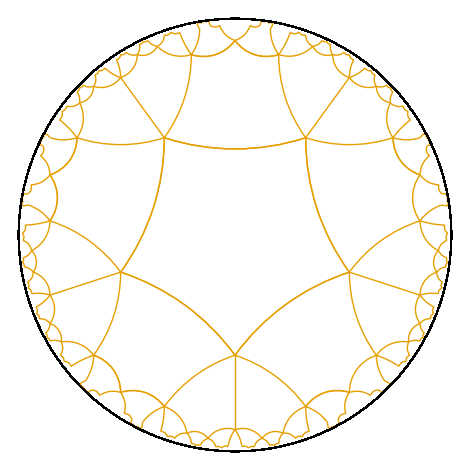

In [4]:
# First set a precision, which will stay constant throughout 
P = 100
FC = ComplexField(prec=P)

p = 5
q = 5
d = sqrt((tan(pi/2-pi/q)-tan(pi/p))/(tan(pi/2-pi/q)+tan(pi/p)))
d = FC(d)

p1 = -d*I
p2 = p1*exp(2*pi*I/5)
gf = HypLine(p1, p2, prec=P)

gf2 = gf.centralRot(2*pi/5)
gf3 = gf.reflect(gf2)
gf4 = gf3.centralRot(-2*pi/5)
gf5 = gf.reflect(gf4)

print("Starting reflections:")
ct = time()
# Make the first rotations of the line
old = [gf]+[gf.centralRot(2*pi*k/5) for k in range(1,5)] #+ [gf5]
print(len(old))

# gf6 = gf5.reflect(gf4)
# gf7 = gf6.reflect(gf2)
# gf8 = gf5.reflect(gf7)

# First refelection process
new = []
for gi in old:
    for gj in old:
        if gi.is_equal(gj):
            continue
        gn = gi.reflect(gj)
        if any([gn.is_equal(gk) for gk in new]):
            continue
        new.append(gn)
# first_ref = [gi.reflect(gj) for gi in initial 
#              for gj in initial if not gi.is_equal(gj)]
print(len(new))
old = new
new = []
for gi in old:
    for gj in old:
        if gi.is_equal(gj):
            continue
        gn = gi.reflect(gj)
        if any([gn.is_equal(gk) for gk in new]):
            continue
        new.append(gn)
# Second reflection process

# second_ref = [gi.reflect(gj) for gi in first_ref
#              for gj in first_ref if not gi.is_equal(gj)]
print(len(new))

second_ref_55 = new
print("Took {} seconds".format(time()-ct))

# To avoid over-plotting we now want some trimming process. 
# This is the slowest part, and really would be improved by just not reflecting as much
# Because lines are approximate, we have to give our own method to check equality. 

# print("Starting post-processing:")
# ct = time()
# unique = []
# for gi in second_ref:
#     if not any([gi.is_equal(gj) for gj in unique]):
#         unique.append(gi)
# print("Took {} seconds".format(time()-ct))

# We now know we will be plotting inside the edges cut off from BN. 
# If we weren't these steps wouldn't be relevant. 
# We post-process the set of lines some more. 
new = second_ref_55 + [gf5.centralRot(2*pi*k/5) for k in range(5)]

Fig_55 = sum([gi.plot(color=cbbP[1]) for gi in new])
Fig_55